# Synthetic All-of-Us / OMOP data → correlated free-text notes → future-lab targets

This notebook builds an end-to-end synthetic pipeline for training a language model with
**quantile-regression heads** to predict future laboratory values from clinical free text.

**Pipeline**
1. `generate_omop_dataset(n)` — draw `n` synthetic participants structured on the
   [OMOP Common Data Model](https://ohdsi.github.io/CommonDataModel/) as used by the
   NIH *All-of-Us* Research Program, including *All-of-Us* survey (PPI) modules
   (*The Basics*, *Lifestyle*, *Overall Health*).
2. `generate_encounter_note(...)` — for every unique encounter date of every patient,
   emit a free-text note capturing the patient's **current status across every OMOP table**,
   printing both the human-readable concept **name** and the source **code**.
3. `simulate_final_labs(...)` — at each patient's **last** encounter, simulate five LOINC
   lab measures whose distributions are **deliberately correlated** with data elements that
   appear in the earlier notes (adiposity, diabetes, alcohol use, physical activity, meds).
4. `build_stu_context(...)` + `build_long_form(...)` — the `text` (context up to the
   **second-to-last** encounter) is built with the uploaded `module_structured_to_unstructured.py`,
   and the output is written **long-form** (`id, code, question, text, value`) with one row per
   patient × lab measured at the **last** encounter.

**Target labs (LOINC)**

| Code | Analyte |
|---|---|
| `2091-7` | Cholesterol in VLDL [Mass/volume], Serum/Plasma |
| `3043-7` | Triglyceride [Mass/volume], Blood |
| `4548-4` | Hemoglobin A1c / Hemoglobin.total, Blood |
| `1742-6` | Alanine aminotransferase (ALT), Serum/Plasma |
| `1920-8` | Aspartate aminotransferase (AST), Serum/Plasma |

**Verified equations / references used to make the labs realistic and correlated**
- **VLDL-C = Triglycerides / 5** (mg/dL), valid for TG < 400 mg/dL — Friedewald WT, Levy RI,
  Fredrickson DS. *Clin Chem.* 1972;18(6):499–502.
- **Estimated average glucose eAG (mg/dL) = 28.7 × HbA1c(%) − 46.7** — Nathan DM et al.
  (ADAG study). *Diabetes Care.* 2008;31(8):1473–1478.
- **De Ritis ratio (AST/ALT) > 2** suggests alcohol-related liver injury — Botros M, Sikaris KA.
  *Clin Biochem Rev.* 2013;34(3):117–130.
- **BMI = weight(kg) / height(m)²** — Quetelet / WHO.

> ⚠️ **Codes.** LOINC / SNOMED / RxNorm / OMOP visit & gender codes are real. The integer
> `concept_id`s are **illustrative placeholders**; in a production *All-of-Us* build they map to
> [OHDSI Athena](https://athena.ohdsi.org/) `concept_id`s. Survey items use *All-of-Us* PPI-style
> source values. This is **synthetic data** — not derived from any real participant.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
from datetime import date, timedelta

In [2]:
#set modules path to your repository's local src path
module_path = os.path.abspath("/home/jupyter/repos/hydralab_cqr/src")
if module_path not in sys.path:
    sys.path.append(module_path)

import module_structured_to_unstructured_rebuild as stu_mod

In [3]:
RNG_SEED = 77030
N_PATIENTS = 1000
SPLIT_SEED = 57006
TEST_SIZE  = 0.20 # holdout fraction (0.20 = 80% train / 20% test)

In [4]:
#change to your working directory
os.chdir("/home/jupyter/repos/hydralab_cqr/workflow_to_update_hydralab_cqr_example")

In [5]:
pd.set_option("display.max_colwidth", 120)

## 1. Controlled vocabulary

A single registry maps each clinical element to its `concept_id`, source `vocabulary`, source
`code`, display `name`, `domain`, and (for measurements) `unit`. Every table row and every note
references this registry, guaranteeing that the note always contains **both name and code**.

In [6]:
CONCEPTS = {
    # Conditions (SNOMED)
    "t2dm":        dict(cid=201826,  vocab="SNOMED", code="44054006",  name="Type 2 diabetes mellitus",            domain="Condition"),
    "htn":         dict(cid=320128,  vocab="SNOMED", code="59621000",  name="Essential hypertension",              domain="Condition"),
    "obesity":     dict(cid=433736,  vocab="SNOMED", code="414916001", name="Obesity",                             domain="Condition"),
    "hld":         dict(cid=432867,  vocab="SNOMED", code="55822004",  name="Hyperlipidemia",                      domain="Condition"),
    "masld":       dict(cid=4059290, vocab="SNOMED", code="197315008", name="Non-alcoholic fatty liver disease",   domain="Condition"),
    # Drugs (RxNorm ingredient)
    "metformin":   dict(cid=1503297, vocab="RxNorm", code="6809",  name="Metformin",     domain="Drug"),
    "atorvastatin":dict(cid=1545958, vocab="RxNorm", code="83367", name="Atorvastatin",  domain="Drug"),
    "lisinopril":  dict(cid=1308216, vocab="RxNorm", code="29046", name="Lisinopril",    domain="Drug"),
    # Measurements: vitals (LOINC)
    "bmi":    dict(cid=3038553, vocab="LOINC", code="39156-5", name="Body mass index (BMI) [Ratio]",   domain="Measurement", unit="kg/m2"),
    "sbp":    dict(cid=3004249, vocab="LOINC", code="8480-6",  name="Systolic blood pressure",         domain="Measurement", unit="mmHg"),
    "dbp":    dict(cid=3012888, vocab="LOINC", code="8462-4",  name="Diastolic blood pressure",        domain="Measurement", unit="mmHg"),
    # Measurements: TARGET labs (LOINC, provided by task)
    "vldl":   dict(cid=3022038, vocab="LOINC", code="2091-7", name="Cholesterol in VLDL [Mass/volume] in Serum or Plasma",                         domain="Measurement", unit="mg/dL"),
    "trig":   dict(cid=3022192, vocab="LOINC", code="3043-7", name="Triglyceride [Mass/volume] in Blood",                                          domain="Measurement", unit="mg/dL"),
    "a1c":    dict(cid=3004410, vocab="LOINC", code="4548-4", name="Hemoglobin A1c/Hemoglobin.total in Blood",                                     domain="Measurement", unit="%"),
    "alt":    dict(cid=3006923, vocab="LOINC", code="1742-6", name="Alanine aminotransferase (ALT) [Enzymatic activity/volume] in Serum or Plasma",domain="Measurement", unit="U/L"),
    "ast":    dict(cid=3013721, vocab="LOINC", code="1920-8", name="Aspartate aminotransferase (AST) [Enzymatic activity/volume] in Serum or Plasma",domain="Measurement", unit="U/L"),
    # Survey items (All-of-Us PPI style; Lifestyle / Overall Health)
    "alcohol_freq":dict(cid=1586201, vocab="PPI", code="Alcohol_DrinkFrequency",     name="Alcohol use: drink frequency (past year)",       domain="Observation"),
    "smoke_status":dict(cid=1585860, vocab="PPI", code="Smoking_SmokeFrequency",     name="Smoking: current cigarette use",                 domain="Observation"),
    "phys_act":    dict(cid=1585710, vocab="PPI", code="Lifestyle_ModeratePADays",   name="Physical activity: days/week moderate activity", domain="Observation"),
    "diet":        dict(cid=1585790, vocab="PPI", code="OverallHealth_DietQuality",  name="Self-reported diet quality",                     domain="Observation"),
}
TARGET_LABS = ["vldl", "trig", "a1c", "alt", "ast"]

# All-of-Us style survey answer text
ALCOHOL_ANSWERS = {0:"Never", 1:"Monthly or less", 2:"2 to 4 times a month",
                   3:"2 to 3 times a week", 4:"4 or more times a week"}
SMOKE_ANSWERS   = {0:"Not at all (never smoker)", 1:"Not at all (former smoker)",
                   2:"Some days", 3:"Every day"}
DIET_ANSWERS    = {0:"Poor", 1:"Fair", 2:"Good", 3:"Very good", 4:"Excellent"}

concept_df = pd.DataFrame(CONCEPTS).T
concept_df.index.name = "key"
concept_df

,cid,vocab,code,name,domain,unit
key,,,,,,
t2dm,201826,SNOMED,44054006,Type 2 diabetes mellitus,Condition,NaN
htn,320128,SNOMED,59621000,Essential hypertension,Condition,NaN
obesity,433736,SNOMED,414916001,Obesity,Condition,NaN
hld,432867,SNOMED,55822004,Hyperlipidemia,Condition,NaN
masld,4059290,SNOMED,197315008,Non-alcoholic fatty liver disease,Condition,NaN
metformin,1503297,RxNorm,6809,Metformin,Drug,NaN
atorvastatin,1545958,RxNorm,83367,Atorvastatin,Drug,NaN
lisinopril,1308216,RxNorm,29046,Lisinopril,Drug,NaN
bmi,3038553,LOINC,39156-5,Body mass index (BMI) [Ratio],Measurement,kg/m2


## 2. Hidden phenotype (ground-truth generator)

Each participant is drawn from a latent phenotype: adiposity, behaviours (alcohol, smoking,
physical activity, diet), and downstream disease probabilities. This latent state is the
**causal root** — it drives (a) the OMOP records that appear in the notes and (b) the future
labs. The latent frame is returned separately and is **never shown to the model**; it exists
only so we can audit that the intended correlations are present.

In [7]:
def sample_latent(rng, pid):
    """
    Draw the hidden ground-truth phenotype for one synthetic participant.

    Parameters
   -------
    rng : numpy.random.Generator
        Seeded random generator for reproducibility.
    pid : int
        Person identifier assigned to this participant.

    Returns
   ----
    dict
        Latent phenotype with keys:
        person_id (int), sex (str), age0 (int, age at first visit),
        bmi0 (float, baseline BMI in kg/m^2), obese (bool),
        alcohol (int 0-4, All-of-Us drink-frequency level),
        smoke (int 0-3), pa_days (int 0-7 moderate-activity days/week),
        diet (int 0-4, quality), diabetes (bool), glyc_burden (float 0-1,
        latent glycaemic severity), masld(bool), hln (bool hyperlipidemia),
        htn (bool), statin (bool), metformin (bool).

    Notes
   --
    Disease probabilities use logistic links on BMI and age, e.g.
        P(diabetes) = sigmoid(-4.0 + 0.10*(BMI-25) + 0.03*(age-50)),
    so higher adiposity/age raise diabetes risk. `glyc_burden` is drawn tightly
    per diabetes status so the *text-visible* diabetes flag carries the HbA1c signal.
    """
    sex   = rng.choice(["Female", "Male"])
    age0  = int(rng.integers(30, 80))
    bmi0  = float(np.clip(rng.normal(29, 6), 17, 55))
    obese = bmi0 >= 30
    alcohol = int(rng.choice([0,1,2,3,4], p=[0.30,0.28,0.22,0.12,0.08]))
    smoke   = int(rng.choice([0,1,2,3],   p=[0.55,0.20,0.10,0.15]))
    pa_days = int(rng.integers(0, 8))
    diet    = int(rng.choice([0,1,2,3,4], p=[0.10,0.25,0.35,0.20,0.10]))

    p_dm = 1/(1+np.exp(-(-4.0 + 0.10*(bmi0-25) + 0.03*(age0-50))))
    diabetes = bool(rng.random() < p_dm)
    glyc_burden = float(np.clip(rng.beta(6,3) if diabetes else rng.beta(2,10), 0, 1))

    p_masld = 1/(1+np.exp(-(-3.2 + 0.14*(bmi0-25) + 0.30*alcohol)))
    masld = bool(rng.random() < p_masld)
    hln = bool(rng.random() < (0.25 + 0.02*(bmi0-25)))
    htn = bool(rng.random() < 1/(1+np.exp(-(-2.5 + 0.06*(bmi0-25) + 0.04*(age0-50)))))
    statin = bool(hln and rng.random() < 0.70)
    metformin = bool(diabetes and rng.random() < 0.75)

    return dict(person_id=pid, sex=sex, age0=age0, bmi0=bmi0, obese=obese,
                alcohol=alcohol, smoke=smoke, pa_days=pa_days, diet=diet,
                diabetes=diabetes, glyc_burden=glyc_burden, masld=masld,
                hln=hln, htn=htn, statin=statin, metformin=metformin)

## 3. Correlated future labs

At the last encounter we sample the five target labs from the final phenotype. Effects are wired
to be **learnable from the notes** and to include **heteroscedastic** structure (spread that
depends on text-visible drivers) — the exact regime where quantile heads beat a fixed-width
baseline.

In [8]:
def simulate_final_labs(rng, lat, bmi_final):
    """
    Simulate the five LOINC target labs at a participant's final encounter.

    Parameters
   -------
    rng : numpy.random.Generator
        Seeded random generator.
    lat : dict
        Latent phenotype from `sample_latent`.
    bmi_final : float
        BMI (kg/m^2) at the final encounter (end of the drift trajectory).

    Returns
   ----
    dict
        {"vldl","trig","a1c","alt","ast"} mapped to numeric lab values in the
        LOINC-appropriate units (VLDL/TG mg/dL, A1c %, ALT/AST U/L).

    Verified equations & references
   ----------------------------
    * VLDL-C = TG / 5  (mg/dL), valid TG < 400 mg/dL.
      Friedewald WT, Levy RI, Fredrickson DS. Clin Chem. 1972;18(6):499-502.
    * De Ritis ratio AST/ALT rises with alcohol (heavy use -> ratio > 2).
      Botros M, Sikaris KA. Clin Biochem Rev. 2013;34(3):117-130.

    Correlation design (all drivers below appear in the notes except glyc_burden)
   --------------------------------------------------------------------------
    Triglycerides ~ LogNormal, mean rises with BMI, diabetes, alcohol; falls with
      physical activity, statin, diet quality. Residual SD grows with alcohol
      (heteroscedastic).  VLDL is derived from TG via Friedewald (+small noise).
    HbA1c mean rises with BMI and glyc_burden (tightly tied to the diabetes flag),
      falls with metformin and activity; residual SD grows with diabetes.
    ALT/AST ~ LogNormal, rise with BMI, masld, alcohol; AST scales faster with
      alcohol than ALT, reproducing the De Ritis pattern.
    """
    a, pa = lat["alcohol"], lat["pa_days"]

    # Triglycerides (mg/dL)
    mu_tg = (np.log(110) + 0.028*(bmi_final-25) + 0.30*lat["diabetes"]
             + 0.18*a - 0.03*pa - 0.25*lat["statin"] - 0.05*lat["diet"])
    sd_tg = 0.18 + 0.06*a                                   # heteroscedastic
    tg = float(np.clip(np.exp(mu_tg + rng.normal(0, sd_tg)), 40, 900))

    # VLDL via Friedewald (TG/5)
    vldl = float(np.clip(tg/5.0 + rng.normal(0, 1.5), 2, 200))

    # HbA1c (%)
    mu_a1c = (5.3 + 0.020*(bmi_final-25) + 2.2*lat["glyc_burden"]
              - 0.40*lat["metformin"] - 0.02*pa)
    sd_a1c = 0.20 + 0.55*lat["diabetes"]                    # heteroscedastic
    a1c = float(np.clip(mu_a1c + rng.normal(0, sd_a1c), 4.4, 14.5))

    # ALT / AST (U/L)
    mu_alt = np.log(22) + 0.030*(bmi_final-25) + 0.28*lat["masld"] + 0.14*a
    alt = float(np.clip(np.exp(mu_alt + rng.normal(0, 0.22)), 7, 400))
    mu_ast = np.log(20) + 0.018*(bmi_final-25) + 0.16*lat["masld"] + 0.30*a
    ast = float(np.clip(np.exp(mu_ast + rng.normal(0, 0.22)), 8, 400))

    return dict(vldl=round(vldl,1), trig=round(tg,0), a1c=round(a1c,1),
                alt=round(alt,0), ast=round(ast,0))


def _order_labs(rng, lat):
    """
    Decide which of the five target labs are actually *ordered* at the final visit.

    Parameters
   -------
    rng : numpy.random.Generator
        Seeded generator.
    lat : dict
        Latent phenotype from `sample_latent`.

    Returns
   ----
    list[str]
        Subset of TARGET_LABS actually measured. VLDL+Triglyceride are ordered
        together as a lipid panel; ALT+AST together as a hepatic panel; HbA1c on
        its own. Ordering probabilities depend on phenotype, so labs are
        missing-not-at-random (as in real EHR / All-of-Us data) and different
        patients yield different long-form row sets.
    """
    ordered = []
    p_lipid = min(0.95, 0.75 + 0.10*(lat["hln"] or lat["statin"]))
    if rng.random() < p_lipid:
        ordered += ["vldl", "trig"]
    p_a1c = min(0.95, 0.55 + 0.30*lat["diabetes"] + 0.10*lat["obese"])
    if rng.random() < p_a1c:
        ordered += ["a1c"]
    p_lft = min(0.95, 0.55 + 0.20*lat["masld"] + 0.15*(lat["alcohol"] >= 3) + 0.10*lat["statin"])
    if rng.random() < p_lft:
        ordered += ["alt", "ast"]
    return ordered

## 4. OMOP dataset generator

`generate_omop_dataset(n)` produces standard OMOP-style tables (`person`, `visit_occurrence`,
`condition_occurrence`, `drug_exposure`, `measurement`, `observation`). Conditions carry an onset
date and are *active* at every later encounter; drugs are ongoing from start; vitals are recorded
each visit on a slow BMI-drift trajectory; *All-of-Us* survey items are recorded at the baseline
visit; the five target labs are recorded **only at the final encounter**.

In [9]:
def generate_omop_dataset(n, seed=RNG_SEED):
    """
    Generate a synthetic All-of-Us/OMOP dataset of `n` participants.

    Parameters
   -------
    n : int
        Number of synthetic participants to generate.
    seed : int, optional
        Random seed (default RNG_SEED) for full reproducibility.

    Returns
   ----
    tables : dict[str, pandas.DataFrame]
        OMOP-style tables: 'person', 'visit_occurrence', 'condition_occurrence',
        'drug_exposure', 'measurement', 'observation'. Each clinical row carries
        its concept_id, source code, concept_name and vocabulary so notes can be
        rendered directly from the tables.
    latent : pandas.DataFrame
        One row per participant with the hidden phenotype plus '_final_labs'
        (dict of the five targets) and '_bmi_final'. This is GROUND TRUTH for
        auditing only and must NOT be fed to the model.

    Notes
   --
    BMI drift uses a random walk; the final BMI feeds `simulate_final_labs`.
    Target labs appear only at the last visit (no leakage into feature notes).
    """
    rng = np.random.default_rng(seed)
    persons=[]; visits=[]; conds=[]; drugs=[]; meas=[]; obs=[]; latents=[]
    vid=cid=did=mid=oid=1

    for pid in range(1, n+1):
        lat = sample_latent(rng, pid)
        persons.append(dict(person_id=pid, gender=lat["sex"],
                            gender_concept_id=8532 if lat["sex"]=="Female" else 8507,
                            year_of_birth=2024-lat["age0"], age_at_enroll=lat["age0"]))

        n_visits = int(rng.integers(3, 8))
        d0 = date(2019,1,1) + timedelta(days=int(rng.integers(0,900)))
        vdates=[]; d=d0
        for _ in range(n_visits):
            vdates.append(d); d = d + timedelta(days=int(rng.integers(90,270)))

        active_conditions=[]
        for key, present in [("t2dm",lat["diabetes"]),("htn",lat["htn"]),
                             ("obesity",lat["obese"]),("hld",lat["hln"]),("masld",lat["masld"])]:
            if present:
                onset = vdates[0] - timedelta(days=int(rng.integers(0,1500)))
                active_conditions.append((key, onset))

        drug_list=[k for k,present in [("metformin",lat["metformin"]),
                    ("atorvastatin",lat["statin"]),
                    ("lisinopril", lat["htn"] and rng.random()<0.6)] if present]

        bmi_traj = lat["bmi0"] + np.cumsum(rng.normal(0.1, 0.4, n_visits))

        for i, vd in enumerate(vdates):
            visits.append(dict(visit_occurrence_id=vid, person_id=pid, visit_concept_id=9202,
                               visit_source_value="Outpatient Visit",
                               visit_start_date=vd, visit_end_date=vd, visit_index=i))
            for key, onset in active_conditions:
                if onset <= vd:
                    c=CONCEPTS[key]
                    conds.append(dict(condition_occurrence_id=cid, person_id=pid, visit_occurrence_id=vid,
                                      condition_concept_id=c["cid"], condition_start_date=onset,
                                      condition_source_value=c["code"], concept_name=c["name"],
                                      vocabulary_id=c["vocab"], key=key)); cid+=1
            for key in drug_list:
                c=CONCEPTS[key]
                drugs.append(dict(drug_exposure_id=did, person_id=pid, visit_occurrence_id=vid,
                                  drug_concept_id=c["cid"], drug_exposure_start_date=vd,
                                  drug_source_value=c["code"], concept_name=c["name"],
                                  vocabulary_id=c["vocab"], key=key)); did+=1

            bmi_i = float(np.clip(bmi_traj[i], 16, 60))
            sbp = float(np.clip(rng.normal(135 if lat["htn"] else 120, 10), 90, 200))
            dbp = float(np.clip(rng.normal(85  if lat["htn"] else 76, 7), 55, 120))
            for key, val in [("bmi",round(bmi_i,1)),("sbp",round(sbp)),("dbp",round(dbp))]:
                c=CONCEPTS[key]
                meas.append(dict(measurement_id=mid, person_id=pid, visit_occurrence_id=vid,
                                 measurement_concept_id=c["cid"], measurement_date=vd,
                                 value_as_number=val, unit_source_value=c["unit"],
                                 measurement_source_value=c["code"], concept_name=c["name"],
                                 vocabulary_id=c["vocab"], key=key, is_target=False)); mid+=1

            if i == 0:   # baseline All-of-Us surveys
                for key, ans in [("alcohol_freq",ALCOHOL_ANSWERS[lat["alcohol"]]),
                                 ("smoke_status",SMOKE_ANSWERS[lat["smoke"]]),
                                 ("phys_act", f"{lat['pa_days']} days/week"),
                                 ("diet", DIET_ANSWERS[lat["diet"]])]:
                    c=CONCEPTS[key]
                    obs.append(dict(observation_id=oid, person_id=pid, visit_occurrence_id=vid,
                                    observation_concept_id=c["cid"], observation_date=vd,
                                    value_as_string=ans, observation_source_value=c["code"],
                                    concept_name=c["name"], vocabulary_id=c["vocab"], key=key)); oid+=1

            if i == n_visits-1:   # FINAL encounter -> target labs (sparsely ordered)
                labs = simulate_final_labs(rng, lat, bmi_i)   # all 5 simulated = latent truth (audit)
                lat["_final_labs"]=labs; lat["_bmi_final"]=bmi_i
                ordered = _order_labs(rng, lat)               # subset actually measured
                lat["_ordered_labs"]=ordered
                for key in ordered:
                    c=CONCEPTS[key]
                    meas.append(dict(measurement_id=mid, person_id=pid, visit_occurrence_id=vid,
                                     measurement_concept_id=c["cid"], measurement_date=vd,
                                     value_as_number=labs[key], unit_source_value=c["unit"],
                                     measurement_source_value=c["code"], concept_name=c["name"],
                                     vocabulary_id=c["vocab"], key=key, is_target=True)); mid+=1
            vid+=1
        latents.append(lat)

    tables = dict(
        person=pd.DataFrame(persons),
        visit_occurrence=pd.DataFrame(visits),
        condition_occurrence=pd.DataFrame(conds),
        drug_exposure=pd.DataFrame(drugs),
        measurement=pd.DataFrame(meas),
        observation=pd.DataFrame(obs))
    return tables, pd.DataFrame(latents)

In [10]:
tables, latent = generate_omop_dataset(N_PATIENTS)
for name, df in tables.items():
    print(f"{name:22s} rows={len(df):6d}  cols={df.shape[1]}")
tables["measurement"].head(8)

person                 rows=  1000  cols=5
visit_occurrence       rows=  4956  cols=7
condition_occurrence   rows=  5081  cols=9
drug_exposure          rows=  1641  cols=9
measurement            rows= 18322  cols=12
observation            rows=  4000  cols=10


,measurement_id,person_id,visit_occurrence_id,measurement_concept_id,measurement_date,value_as_number,unit_source_value,measurement_source_value,concept_name,vocabulary_id,key,is_target
0,1,1,1,3038553,2020-10-28,40.3,kg/m2,39156-5,Body mass index (BMI) [Ratio],LOINC,bmi,False
1,2,1,1,3004249,2020-10-28,117.0,mmHg,8480-6,Systolic blood pressure,LOINC,sbp,False
2,3,1,1,3012888,2020-10-28,69.0,mmHg,8462-4,Diastolic blood pressure,LOINC,dbp,False
3,4,1,2,3038553,2021-05-29,40.5,kg/m2,39156-5,Body mass index (BMI) [Ratio],LOINC,bmi,False
4,5,1,2,3004249,2021-05-29,99.0,mmHg,8480-6,Systolic blood pressure,LOINC,sbp,False
5,6,1,2,3012888,2021-05-29,76.0,mmHg,8462-4,Diastolic blood pressure,LOINC,dbp,False
6,7,1,3,3038553,2021-11-03,40.6,kg/m2,39156-5,Body mass index (BMI) [Ratio],LOINC,bmi,False
7,8,1,3,3004249,2021-11-03,112.0,mmHg,8480-6,Systolic blood pressure,LOINC,sbp,False


## 5. Free-text note per encounter

For **every unique encounter date of every patient**, `generate_encounter_note` walks each OMOP
table and renders the patient's **current status** at that time — every item shown as
`Name [VOCAB CODE]`. `generate_all_notes` returns one row per (patient, encounter).

In [11]:
def _index_tables(tables):
    """Pre-group OMOP tables by person_id / visit for fast note rendering.

    Parameters
   -------
    tables : dict[str, pandas.DataFrame]
        Output of `generate_omop_dataset`.

    Returns
   ----
    dict
        Lookup structures keyed by person_id (conditions, drugs, observations)
        and by visit_occurrence_id (measurements), plus the person table indexed
        by person_id.
    """
    return dict(
        person = tables["person"].set_index("person_id"),
        cond   = {p:g for p,g in tables["condition_occurrence"].groupby("person_id")},
        drug   = {p:g for p,g in tables["drug_exposure"].groupby("person_id")},
        obs    = {p:g for p,g in tables["observation"].groupby("person_id")},
        meas_v = {v:g for v,g in tables["measurement"].groupby("visit_occurrence_id")},
    )


def generate_encounter_note(pid, visit_row, idx, include_target_labs=False):
    """
    Render a free-text clinical note describing a patient's status at one encounter.

    Parameters
   -------
    pid : int
        Person identifier.
    visit_row : pandas.Series
        A row of `visit_occurrence` (needs visit_occurrence_id, visit_start_date,
        visit_source_value, visit_concept_id).
    idx : dict
        Output of `_index_tables`.
    include_target_labs : bool, optional
        If False (default) the five target labs are omitted from the note even
        when present at this visit — used to keep the FINAL encounter's labs out
        of the feature text. If True, target labs are rendered too.

    Returns
   ----
    str
        A multi-line note. Every clinical element is written as
        ``Name [VOCABULARY CODE]`` so both the textual description and the raw
        OMOP source code appear. Sections cover: demographics (person),
        visit_occurrence, active problems (condition_occurrence), current
        medications (drug_exposure), measurements (measurement), and
        survey/observation (observation).
    """
    vid  = visit_row["visit_occurrence_id"]
    vdate = visit_row["visit_start_date"]
    person = idx["person"].loc[pid]
    lines = []
    # header + demographics (person table)
    lines.append(f"ENCOUNTER NOTE — {vdate} | "
                 f"{visit_row['visit_source_value']} [OMOP {visit_row['visit_concept_id']}] | "
                 f"visit_occurrence_id={vid}")
    age = int(vdate.year - person['year_of_birth'])
    lines.append(f"Patient: person_id {pid}, {age}-year-old {person['gender']} "
                 f"[OMOP {person['gender_concept_id']}].")

    # active problems (condition_occurrence): onset on/before this date, de-duplicated
    lines.append("Active problems:")
    cg = idx["cond"].get(pid)
    active = []
    if cg is not None:
        cg = cg[cg["condition_start_date"] <= vdate].drop_duplicates("key")
        for _, r in cg.iterrows():
            active.append(f"  - {r['concept_name']} [{r['vocabulary_id']} {r['condition_source_value']}] "
                          f"(onset {r['condition_start_date']})")
    lines += active if active else ["  - None documented."]

    # current medications (drug_exposure)
    lines.append("Current medications:")
    dg = idx["drug"].get(pid)
    meds = []
    if dg is not None:
        dg = dg[dg["drug_exposure_start_date"] <= vdate].drop_duplicates("key")
        for _, r in dg.iterrows():
            meds.append(f"  - {r['concept_name']} [{r['vocabulary_id']} {r['drug_source_value']}]")
    lines += meds if meds else ["  - None documented."]

    # measurements at this visit (measurement)
    lines.append("Measurements this encounter:")
    mv = idx["meas_v"].get(vid)
    if mv is not None:
        if not include_target_labs:
            mv = mv[~mv["is_target"]]
        for _, r in mv.iterrows():
            lines.append(f"  - {r['concept_name']} = {r['value_as_number']} {r['unit_source_value']} "
                         f"[{r['vocabulary_id']} {r['measurement_source_value']}]")

    # survey / observation (observation): most recent on/before this date
    lines.append("Survey / social history (All-of-Us PPI):")
    og = idx["obs"].get(pid)
    surv = []
    if og is not None:
        og = og[og["observation_date"] <= vdate].sort_values("observation_date").drop_duplicates("key", keep="last")
        for _, r in og.iterrows():
            surv.append(f"  - {r['concept_name']}: {r['value_as_string']} "
                        f"[{r['vocabulary_id']} {r['observation_source_value']}]")
    lines += surv if surv else ["  - No survey on record as of this date."]

    return "\n".join(lines)


def generate_all_notes(tables):
    """
    Generate one free-text note for every (patient, encounter) pair.

    Parameters
   -------
    tables : dict[str, pandas.DataFrame]
        Output of `generate_omop_dataset`.

    Returns
   ----
    pandas.DataFrame
        Columns: person_id, visit_occurrence_id, visit_index, visit_start_date,
        is_final_encounter (bool), note (str). Notes for non-final encounters
        never contain the target labs; the final-encounter note is rendered
        with the labs included (for inspection only).
    """
    idx = _index_tables(tables)
    vo = tables["visit_occurrence"]
    last_idx = vo.groupby("person_id")["visit_index"].transform("max")
    rows=[]
    for (_, vrow), is_final in zip(vo.iterrows(), (vo["visit_index"]==last_idx).values):
        note = generate_encounter_note(vrow["person_id"], vrow, idx,
                                       include_target_labs=bool(is_final))
        rows.append(dict(person_id=vrow["person_id"],
                         visit_occurrence_id=vrow["visit_occurrence_id"],
                         visit_index=vrow["visit_index"],
                         visit_start_date=vrow["visit_start_date"],
                         is_final_encounter=bool(is_final), note=note))
    return pd.DataFrame(rows)

In [12]:
notes = generate_all_notes(tables)
print(f"Generated {len(notes)} encounter notes for {notes['person_id'].nunique()} patients.\n")
# Show a full patient trajectory (all encounters)
pid0 = notes["person_id"].iloc[0]
for _, r in notes[notes["person_id"]==pid0].iterrows():
    tag = "  <-- FINAL (contains target labs)" if r["is_final_encounter"] else ""
    print("="*100 + tag)
    print(r["note"])

Generated 4956 encounter notes for 1000 patients.

ENCOUNTER NOTE — 2020-10-28 | Outpatient Visit [OMOP 9202] | visit_occurrence_id=1
Patient: person_id 1, 49-year-old Female [OMOP 8532].
Active problems:
  - Obesity [SNOMED 414916001] (onset 2017-04-22)
Current medications:
  - None documented.
Measurements this encounter:
  - Body mass index (BMI) [Ratio] = 40.3 kg/m2 [LOINC 39156-5]
  - Systolic blood pressure = 117.0 mmHg [LOINC 8480-6]
  - Diastolic blood pressure = 69.0 mmHg [LOINC 8462-4]
Survey / social history (All-of-Us PPI):
  - Alcohol use: drink frequency (past year): Never [PPI Alcohol_DrinkFrequency]
  - Smoking: current cigarette use: Some days [PPI Smoking_SmokeFrequency]
  - Physical activity: days/week moderate activity: 5 days/week [PPI Lifestyle_ModeratePADays]
  - Self-reported diet quality: Very good [PPI OverallHealth_DietQuality]
ENCOUNTER NOTE — 2021-05-29 | Outpatient Visit [OMOP 9202] | visit_occurrence_id=2
Patient: person_id 1, 50-year-old Female [OMOP 853

## 6. Build the `text` column with STU module

The `text` column is produced by your uploaded **`module_structured_to_unstructured.py`**:

1. Every OMOP domain (demographics, problems, medications, measurements, survey) is rendered to
   pseudo-text with `structured_to_unstructured(...)` — multi-column concatenation of
   `concept_name`, value/units, and `vocab + code`, tagged with a `stu_domain`.
2. `cumulative_concatenator(...)` builds the **per-patient cumulative context**, de-duplicating
   repeated strings (chronic problems collapse to one mention) and keeping only events within the
   lookback window, anchored at each patient's latest **pre-final** encounter — i.e. the
   **second-to-last** encounter overall.

The **final encounter is excluded** before concatenation, so the target labs never leak into `text`.

> Runs the module unmodified; we only pass `date_time_errors_handling='coerce'` explicitly because
> pandas ≥ 3.0 removed the `errors='ignore'` option that the module defaults to.

In [13]:
def build_stu_context(tables, lookback_days=3650):
    """
    Build per-patient cumulative context text using the user-provided STU module.

    Parameters
   -------
    tables : dict[str, pandas.DataFrame]
        Output of `generate_omop_dataset`.
    lookback_days : int, optional
        Lookback window (days) passed to `cumulative_concatenator`. Default 3650
        (~10 years) so the full pre-final history is retained.

    Returns
   ----
    pandas.DataFrame
        Columns: person_id (int), text (str, the concatenated STU context ending
        at the second-to-last encounter), n_context_encounters (int),
        context_end_date (datetime, date of the second-to-last encounter).

    Notes
   --
    The final encounter's rows are removed before concatenation, so the anchor
    date becomes the second-to-last encounter and the target labs cannot leak.
    Each domain is rendered via `structured_to_unstructured` and stacked; the
    stack is collapsed by `cumulative_concatenator`.
    """
    vo = tables["visit_occurrence"]
    final_vid = vo.sort_values("visit_index").groupby("person_id")["visit_occurrence_id"].last()
    final_set = set(final_vid.values)
    vdate = vo.set_index("visit_occurrence_id")["visit_start_date"]

    def _stu(df, domain, dt_col, cols, seps, prefix, end):
        return stu_mod.structured_to_unstructured(
            df, domain, "person_id", dt_col, cols_to_concat=cols,
            concat_syntax_separator_list=seps, prefix_prompt=prefix, end_prompt=end,
            date_time_errors_handling="coerce")

    frames = []

    # Demographics (one row per patient, at first visit)
    first = vo[vo["visit_index"] == 0][["person_id", "visit_start_date"]]
    demo = tables["person"].merge(first, on="person_id")
    demo["age"] = demo["visit_start_date"].map(lambda d: d.year) - demo["year_of_birth"]
    demo["demo"] = demo["age"].astype(str) + "-year-old " + demo["gender"]
    demo["code_str"] = "(OMOP gender " + demo["gender_concept_id"].astype(str) + ")"
    frames.append(_stu(demo, "Demographics", "visit_start_date",
                       ["demo", "code_str"], [" "], "Demographics: ", ". "))

    # Conditions (exclude final visit); dated at the encounter
    cond = tables["condition_occurrence"]
    cond = cond[~cond["visit_occurrence_id"].isin(final_set)].copy()
    cond["dt"] = cond["visit_occurrence_id"].map(vdate)
    cond["code_str"] = "(" + cond["vocabulary_id"] + " " + cond["condition_source_value"] + ")"
    frames.append(_stu(cond, "Condition", "dt",
                       ["concept_name", "code_str"], [" "], "Problem: ", ". "))

    # Medications
    drug = tables["drug_exposure"]
    drug = drug[~drug["visit_occurrence_id"].isin(final_set)].copy()
    drug["dt"] = drug["visit_occurrence_id"].map(vdate)
    drug["code_str"] = "(" + drug["vocabulary_id"] + " " + drug["drug_source_value"] + ")"
    frames.append(_stu(drug, "Drug", "dt",
                       ["concept_name", "code_str"], [" "], "Medication: ", ". "))

    # Measurements: vitals only (exclude target labs and final visit)
    meas = tables["measurement"]
    meas = meas[(~meas["is_target"]) & (~meas["visit_occurrence_id"].isin(final_set))].copy()
    meas["valunit"] = meas["value_as_number"].astype(str) + " " + meas["unit_source_value"].astype(str)
    meas["code_str"] = "(" + meas["vocabulary_id"] + " " + meas["measurement_source_value"] + ")"
    frames.append(_stu(meas, "Measurement", "measurement_date",
                       ["concept_name", "valunit", "code_str"], [" = ", " "], "Measurement: ", ". "))

    # Survey / observation
    obs = tables["observation"]
    obs = obs[~obs["visit_occurrence_id"].isin(final_set)].copy()
    obs["code_str"] = "(" + obs["vocabulary_id"] + " " + obs["observation_source_value"] + ")"
    frames.append(_stu(obs, "Survey", "observation_date",
                       ["concept_name", "value_as_string", "code_str"], [": ", " "], "Survey: ", ". "))

    stacked = pd.concat(frames, ignore_index=True)
    ctx = stu_mod.cumulative_concatenator(
        stacked.copy(), "stu_id", "stu_datetime", "stu_text",
        join_string="; ", lookback_datetime_units=lookback_days, datetime_max_time_lag=0)
    ctx = ctx.rename(columns={"stu_id": "person_id", "stucurrent_text": "text",
                              "last_date_observed": "context_end_date",
                              "encounters": "n_context_encounters"})
    return ctx[["person_id", "text", "n_context_encounters", "context_end_date"]]

In [14]:
context_df = build_stu_context(tables)
print(f"Context built for {len(context_df)} patients.")
display(context_df.head(3))
print("\nExample STU context (person_id "
      f"{context_df['person_id'].iloc[0]}):\n" + "-"*90)
print(context_df["text"].iloc[0][:1400], "\n...[truncated]...")

Context built for 1000 patients.


/home/jupyter/repos/hydralab_cqr/src/module_structured_to_unstructured_rebuild.py:209: FutureWarning: The provided callable <function max at 0x7fef1afd39c0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  maxdatedf = cumdf.groupby([id_column]).agg(max_date=(datetime_column, np.max))
/home/jupyter/repos/hydralab_cqr/src/module_structured_to_unstructured_rebuild.py:221: FutureWarning: The provided callable <function max at 0x7fef1afd39c0> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  lookback_range_df = selcumdf.groupby([id_column]).agg(last_date_observed = (datetime_column, np.max),
/home/jupyter/repos/hydralab_cqr/src/module_structured_to_unstructured_rebuild.py:221: FutureWarning: The provided callable <function min at 0x7fef1afd3b00> is c

,person_id,text,n_context_encounters,context_end_date
0,1,Measurement: Body mass index (BMI) [Ratio] = 40.6 kg/m2 (LOINC 39156-5). ; Measurement: Systolic blood pressure = 11...,3,2021-11-03
1,2,Measurement: Body mass index (BMI) [Ratio] = 27.0 kg/m2 (LOINC 39156-5). ; Measurement: Diastolic blood pressure = 7...,6,2023-01-26
2,3,Measurement: Body mass index (BMI) [Ratio] = 19.4 kg/m2 (LOINC 39156-5). ; Measurement: Systolic blood pressure = 11...,2,2020-11-29



Example STU context (person_id 1):
------------------------------------------------------------------------------------------
Measurement: Body mass index (BMI) [Ratio] = 40.6 kg/m2 (LOINC 39156-5). ; Measurement: Systolic blood pressure = 112.0 mmHg (LOINC 8480-6). ; Measurement: Diastolic blood pressure = 83.0 mmHg (LOINC 8462-4). ; Measurement: Body mass index (BMI) [Ratio] = 40.5 kg/m2 (LOINC 39156-5). ; Measurement: Systolic blood pressure = 99.0 mmHg (LOINC 8480-6). ; Measurement: Diastolic blood pressure = 76.0 mmHg (LOINC 8462-4). ; Demographics: 49-year-old Female (OMOP gender 8532). ; Problem: Obesity (SNOMED 414916001). ; Measurement: Body mass index (BMI) [Ratio] = 40.3 kg/m2 (LOINC 39156-5). ; Measurement: Systolic blood pressure = 117.0 mmHg (LOINC 8480-6). ; Measurement: Diastolic blood pressure = 69.0 mmHg (LOINC 8462-4). ; Survey: Alcohol use: drink frequency (past year): Never (PPI Alcohol_DrinkFrequency). ; Survey: Smoking: current cigarette use: Some days (PPI Smok

### Long-form training file: one row per (patient × measured lab)

`build_long_form` reshapes to the requested schema:

| column | meaning |
|---|---|
| `id` | patient id (MRN-style `person_id`) |
| `code` | LOINC code of the lab to predict |
| `question` | `"What is the predicted value for <name> in <unit> (<LOINC>)?"` |
| `text` | the STU context above (repeats across that patient's labs) |
| `value` | the true observed lab value at the final encounter (numeric, no units) |

Because labs are ordered sparsely (§4), a patient contributes **one row per lab actually measured**
— a lipid-only patient yields 2 rows, a patient with a full panel yields 5, and the shared `text`
repeats down those rows.

In [15]:
def build_long_form(tables, context_df):
    """
    Reshape to the long-form (id, code, question, text, value) training table.

    Parameters
   -------
    tables : dict[str, pandas.DataFrame]
        Output of `generate_omop_dataset`.
    context_df : pandas.DataFrame
        Output of `build_stu_context` (must contain 'person_id' and 'text').

    Returns
   ----
    pandas.DataFrame
        Long-form table with exactly these columns, one row per
        (patient, lab measured at the final encounter):
          id       : int    -- patient identifier
          code     : str    -- LOINC code of the predicted lab
          question : str    -- natural-language prompt naming the analyte + units + LOINC
          text     : str    -- STU context up to the second-to-last encounter
                               (identical across a patient's rows)
          value    : float  -- true observed lab value at the final encounter (no units)

    Notes
   --
    The five labs are emitted in a fixed clinical order (VLDL, TG, A1c, ALT, AST)
    when present. Patients with no labs ordered contribute no rows.
    """
    ctx = context_df.set_index("person_id")["text"]
    tgt = tables["measurement"]
    tgt = tgt[tgt["is_target"]].copy()
    lab_order = {k: i for i, k in enumerate(TARGET_LABS)}
    tgt["ord"] = tgt["key"].map(lab_order)

    rows = []
    for pid, g in tgt.sort_values(["person_id", "ord"]).groupby("person_id", sort=True):
        if pid not in ctx.index:
            continue
        text = ctx.loc[pid]
        for _, r in g.iterrows():
            c = CONCEPTS[r["key"]]
            question = (f"What is the predicted value for {c['name']} "
                        f"in {c['unit']} ({c['code']})?")
            rows.append(dict(id=int(pid), code=c["code"], question=question,
                             text=text, value=float(r["value_as_number"])))
    return pd.DataFrame(rows, columns=["id", "code", "question", "text", "value"])

In [16]:
long_df = build_long_form(tables, context_df)
print(f"Long-form rows: {len(long_df)}  (from {long_df['id'].nunique()} patients)")
print("\nRows per LOINC code:")
display(long_df["code"].value_counts().rename_axis("LOINC").to_frame("rows"))

# Demonstrate the repeated-text long structure for one multi-lab patient
demo_id = long_df["id"].value_counts().idxmax()
sub = long_df[long_df["id"] == demo_id]
print(f"\nPatient id={demo_id} contributes {len(sub)} rows; 'text' repeats (unique texts = "
      f"{sub['text'].nunique()}). Per-row (code, question, value):")
for _, r in sub.iterrows():
    print(f"  code={r['code']:7s} value={r['value']:>7}  | {r['question']}")
print("\nColumns:", list(long_df.columns))
display(long_df.drop(columns=["text"]).head(8))

Long-form rows: 3454  (from 969 patients)

Rows per LOINC code:


,rows
LOINC,
2091-7,788
3043-7,788
1742-6,632
1920-8,632
4548-4,614



Patient id=994 contributes 5 rows; 'text' repeats (unique texts = 1). Per-row (code, question, value):
  code=2091-7  value=   69.9  | What is the predicted value for Cholesterol in VLDL [Mass/volume] in Serum or Plasma in mg/dL (2091-7)?
  code=3043-7  value=  340.0  | What is the predicted value for Triglyceride [Mass/volume] in Blood in mg/dL (3043-7)?
  code=4548-4  value=    6.1  | What is the predicted value for Hemoglobin A1c/Hemoglobin.total in Blood in % (4548-4)?
  code=1742-6  value=   59.0  | What is the predicted value for Alanine aminotransferase (ALT) [Enzymatic activity/volume] in Serum or Plasma in U/L (1742-6)?
  code=1920-8  value=  135.0  | What is the predicted value for Aspartate aminotransferase (AST) [Enzymatic activity/volume] in Serum or Plasma in U/L (1920-8)?

Columns: ['id', 'code', 'question', 'text', 'value']


,id,code,question,value
0,1,2091-7,What is the predicted value for Cholesterol in VLDL [Mass/volume] in Serum or Plasma in mg/dL (2091-7)?,33.2
1,1,3043-7,What is the predicted value for Triglyceride [Mass/volume] in Blood in mg/dL (3043-7)?,162.0
2,1,4548-4,What is the predicted value for Hemoglobin A1c/Hemoglobin.total in Blood in % (4548-4)?,5.7
3,1,1742-6,What is the predicted value for Alanine aminotransferase (ALT) [Enzymatic activity/volume] in Serum or Plasma in U/L...,37.0
4,1,1920-8,What is the predicted value for Aspartate aminotransferase (AST) [Enzymatic activity/volume] in Serum or Plasma in U...,37.0
5,2,2091-7,What is the predicted value for Cholesterol in VLDL [Mass/volume] in Serum or Plasma in mg/dL (2091-7)?,32.3
6,2,3043-7,What is the predicted value for Triglyceride [Mass/volume] in Blood in mg/dL (3043-7)?,168.0
7,2,4548-4,What is the predicted value for Hemoglobin A1c/Hemoglobin.total in Blood in % (4548-4)?,5.3


### Train / holdout split (parameterised, patient-level)

`split_train_holdout` divides the long-form table into an **80% training** file and a **20%
holdout** file. The randomisation is controlled by the **`split_seed`** parameter (default
`SPLIT_SEED`), so the split is reproducible and can be varied independently of the data-generation
seed.

The split is done **by patient id, not by row**: every row for a given patient (all of that
patient's labs, which share the same `text`) goes entirely to train *or* holdout. Splitting by row
would place a patient's identical context in both sets and leak signal into the holdout, inflating
the quantile-interval scores you are trying to measure. Set `group_by_patient=False` only if you
explicitly want a row-level split.

Files are written **with the index** so they reload exactly via
`pd.read_csv(..., index_col=0)`:
`quant_stack_train_test_labdf.csv` (train) and `quant_holdout_labdf.csv` (holdout).

In [17]:
def split_train_holdout(long_df, test_size=TEST_SIZE, split_seed=SPLIT_SEED,
                        id_col="id", group_by_patient=True):
    """
    Split the long-form training table into train and holdout partitions.

    Parameters
   -------
    long_df : pandas.DataFrame
        Long-form table from `build_long_form` (columns id, code, question,
        text, value).
    test_size : float, optional
        Fraction assigned to the holdout set (default TEST_SIZE = 0.20, i.e.
        an 80/20 train/holdout split).
    split_seed : int, optional
        Seed for the random split (default SPLIT_SEED). Varying this re-randomises
        the partition reproducibly and independently of the data-generation seed.
    id_col : str, optional
        Patient identifier column used for grouping (default "id").
    group_by_patient : bool, optional
        If True (default) the split is grouped so all rows for a patient stay
        together, preventing the shared `text` from leaking across partitions.
        If False, a plain row-level shuffle split is used.

    Returns
   ----
    train_df : pandas.DataFrame
        ~ (1 - test_size) of the data, index reset to 0..n-1.
    holdout_df : pandas.DataFrame
        ~ test_size of the data, index reset to 0..m-1.

    Notes
   --
    Grouped splitting rounds the holdout to the nearest whole patient, so the
    realised row fraction may differ slightly from `test_size` when patients
    contribute unequal numbers of labs.
    """
    rng = np.random.default_rng(split_seed)
    if group_by_patient:
        ids = np.array(sorted(long_df[id_col].unique()))
        rng.shuffle(ids)
        n_hold = int(round(test_size * len(ids)))
        hold_ids = set(ids[:n_hold].tolist())
        mask = long_df[id_col].isin(hold_ids)
    else:
        n_hold = int(round(test_size * len(long_df)))
        perm = rng.permutation(len(long_df))
        hold_pos = np.zeros(len(long_df), dtype=bool)
        hold_pos[perm[:n_hold]] = True
        mask = pd.Series(hold_pos, index=long_df.index)
    holdout_df = long_df[mask].reset_index(drop=True)
    train_df   = long_df[~mask].reset_index(drop=True)
    return train_df, holdout_df

In [18]:
train_df, holdout_df = split_train_holdout(long_df, test_size=TEST_SIZE, split_seed=SPLIT_SEED)

n_all = long_df["id"].nunique()
overlap = set(train_df["id"]).intersection(holdout_df["id"])
print(f"split_seed={SPLIT_SEED}  test_size={TEST_SIZE}")
print(f"Patients : {train_df['id'].nunique()} train / {holdout_df['id'].nunique()} holdout "
      f"(of {n_all});  patient overlap = {len(overlap)}")
print(f"Rows     : {len(train_df)} train / {len(holdout_df)} holdout "
      f"({len(holdout_df)/(len(train_df)+len(holdout_df)):.1%} holdout)")
print("\nRows per LOINC code (train vs holdout):")
display(pd.concat([train_df["code"].value_counts().rename("train"),
                   holdout_df["code"].value_counts().rename("holdout")], axis=1))

split_seed=57006  test_size=0.2
Patients : 775 train / 194 holdout (of 969);  patient overlap = 0
Rows     : 2750 train / 704 holdout (20.4% holdout)

Rows per LOINC code (train vs holdout):


,train,holdout
code,,
2091-7,622,166
3043-7,622,166
1742-6,506,126
1920-8,506,126
4548-4,494,120


## 7. Validation — assess that labs are associated with patient specific free text context

We audit against the hidden latent frame (never given to the model). Everything below except
`glyc_burden` is written verbatim into the notes, so these correlations are what a note-reading
model can exploit.

In [19]:
from scipy.stats import spearmanr

aud = latent.copy()
labs = pd.json_normalize(aud["_final_labs"])
aud = pd.concat([aud.drop(columns=["_final_labs"]).reset_index(drop=True), labs], axis=1)
for c in ["diabetes","statin","metformin","masld","obese"]:
    aud[c] = aud[c].astype(int)

feat_labels = {"_bmi_final":"BMI (note)","diabetes":"Diabetes dx (note)",
               "alcohol":"Alcohol level (survey)","pa_days":"Phys activity (survey)",
               "statin":"Statin (drug)","metformin":"Metformin (drug)",
               "masld":"maslddx (note)","glyc_burden":"glyc_burden (HIDDEN)"}
corr = pd.DataFrame({t:[spearmanr(aud[f], aud[t]).statistic for f in feat_labels]
                     for t in TARGET_LABS}, index=list(feat_labels.values()))
print("Spearman correlation: note-visible feature  vs  future lab")
corr.round(2)

Spearman correlation: note-visible feature  vs  future lab


,vldl,trig,a1c,alt,ast
BMI (note),0.32,0.33,0.36,0.56,0.26
Diabetes dx (note),0.19,0.19,0.20,0.05,0.02
Alcohol level (survey),0.55,0.56,0.05,0.49,0.82
Phys activity (survey),-0.16,-0.17,-0.17,-0.01,-0.04
Statin (drug),-0.23,-0.23,0.05,0.16,0.03
Metformin (drug),0.14,0.14,0.16,0.02,0.01
maslddx (note),0.09,0.08,0.04,0.38,0.22
glyc_burden (HIDDEN),0.08,0.07,0.65,0.02,0.01


In [20]:
# Verified-equation checks
aud["deritis"] = aud["ast"]/aud["alt"]
print("Friedewald VLDL = TG/5 :  Spearman(VLDL, TG) =",
      round(spearmanr(aud["vldl"], aud["trig"]).statistic, 3),
      "| median VLDL/(TG/5) =", round((aud["vldl"]/(aud["trig"]/5)).median(), 3))
print("\nDe Ritis AST/ALT ratio by alcohol level (should climb toward >2):")
print(aud.groupby("alcohol")["deritis"].mean().round(2))
print("\neAG(mg/dL)=28.7*A1c-46.7  e.g. A1c 5.5 ->",
      round(28.7*5.5-46.7,1), "mg/dL ; A1c 8.0 ->", round(28.7*8.0-46.7,1), "mg/dL")

Friedewald VLDL = TG/5 :  Spearman(VLDL, TG) = 0.983 | median VLDL/(TG/5) = 1.003

De Ritis AST/ALT ratio by alcohol level (should climb toward >2):
alcohol
0    0.90
1    1.05
2    1.24
3    1.47
4    1.82
Name: deritis, dtype: float64

eAG(mg/dL)=28.7*A1c-46.7  e.g. A1c 5.5 -> 111.1 mg/dL ; A1c 8.0 -> 182.9 mg/dL


In [21]:
# Predictability from NOTE-VISIBLE features only (glyc_burden excluded)
X = aud[["_bmi_final","diabetes","alcohol","pa_days","statin","metformin","masld"]].values
X = np.column_stack([np.ones(len(X)), X])
print("Variance in each future lab explained by note-visible features (OLS R^2):")
for t in TARGET_LABS:
    y = np.log(aud[t].values) if t in ("trig","vldl","alt","ast") else aud[t].values
    beta,_,_,_ = np.linalg.lstsq(X, y, rcond=None)
    yh = X@beta; r2 = 1-((y-yh)**2).sum()/((y-y.mean())**2).sum()
    print(f"  {t:5s}  R^2 = {r2:0.3f}")

Variance in each future lab explained by note-visible features (OLS R^2):
  vldl   R^2 = 0.545
  trig   R^2 = 0.561
  a1c    R^2 = 0.301
  alt    R^2 = 0.616
  ast    R^2 = 0.763


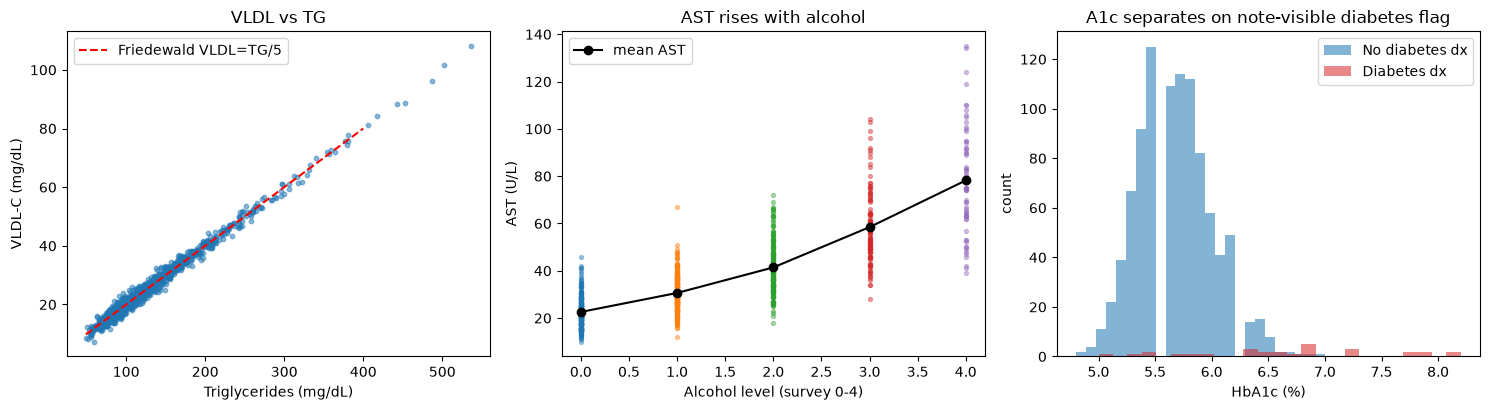

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].scatter(aud["trig"], aud["vldl"], s=10, alpha=0.5)
xs = np.linspace(aud["trig"].min(), min(aud["trig"].max(),400), 50)
ax[0].plot(xs, xs/5, "r--", label="Friedewald VLDL=TG/5")
ax[0].set_xlabel("Triglycerides (mg/dL)"); ax[0].set_ylabel("VLDL-C (mg/dL)")
ax[0].set_title("VLDL vs TG"); ax[0].legend()

for lv in sorted(aud["alcohol"].unique()):
    ax[1].scatter([lv]*(aud["alcohol"]==lv).sum(),
                  aud.loc[aud["alcohol"]==lv,"ast"], s=8, alpha=0.4)
gm = aud.groupby("alcohol")["ast"].mean()
ax[1].plot(gm.index, gm.values, "k-o", label="mean AST")
ax[1].set_xlabel("Alcohol level (survey 0-4)"); ax[1].set_ylabel("AST (U/L)")
ax[1].set_title("AST rises with alcohol"); ax[1].legend()

for d,lab,c in [(0,"No diabetes dx","tab:blue"),(1,"Diabetes dx","tab:red")]:
    ax[2].hist(aud.loc[aud["diabetes"]==d,"a1c"], bins=25, alpha=0.55, label=lab, color=c)
ax[2].set_xlabel("HbA1c (%)"); ax[2].set_ylabel("count")
ax[2].set_title("A1c separates on note-visible diabetes flag"); ax[2].legend()
plt.tight_layout(); plt.show()

In [23]:
from pathlib import Path
out = Path("aou_synthetic_output"); out.mkdir(exist_ok=True)
for name, df in tables.items():
    df.to_csv(out/f"{name}.csv", index=False)
notes.to_csv(out/"encounter_notes.csv", index=False)
context_df.to_csv(out/"stu_context_by_patient.csv", index=False)
concept_df.to_csv(out/"concept_dictionary.csv")

# Full long-form table (all rows) as JSONL, for reference
long_df = long_df[["id", "code", "question", "text", "value"]]
long_df.to_json(out/"text_to_future_labs.jsonl", orient="records", lines=True)

# Train / holdout CSVs. Written WITH the index so they reload via index_col=0.
train_path   = out/"quant_stack_train_test_labdf.csv"
holdout_path = out/"quant_holdout_labdf.csv"
train_df.to_csv(train_path)
holdout_df.to_csv(holdout_path)

print("Wrote:")
for f in sorted(out.iterdir()):
    print(f"  {f}  ({f.stat().st_size/1024:.1f} KB)")

# Verify the exact load syntax round-trips
quant_train_test_labdf = pd.read_csv(train_path, index_col=0)
quant_holdout_labdf    = pd.read_csv(holdout_path, index_col=0)
print("\nReloaded with pd.read_csv(..., index_col=0):")
print("  quant_stack_train_test_labdf.csv ->", quant_train_test_labdf.shape,
      list(quant_train_test_labdf.columns))
print("  quant_holdout_labdf.csv          ->", quant_holdout_labdf.shape,
      list(quant_holdout_labdf.columns))
assert set(quant_train_test_labdf["id"]).isdisjoint(set(quant_holdout_labdf["id"])), \
    "patient leakage between train and holdout!"
print("no patient overlap between train and holdout")

Wrote:
  aou_synthetic_output/concept_dictionary.csv  (1.5 KB)
  aou_synthetic_output/condition_occurrence.csv  (345.8 KB)
  aou_synthetic_output/drug_exposure.csv  (111.7 KB)
  aou_synthetic_output/encounter_notes.csv  (4596.0 KB)
  aou_synthetic_output/measurement.csv  (1766.2 KB)
  aou_synthetic_output/observation.csv  (472.9 KB)
  aou_synthetic_output/person.csv  (22.5 KB)
  aou_synthetic_output/quant_holdout_labdf.csv  (945.4 KB)
  aou_synthetic_output/quant_stack_train_test_labdf.csv  (3709.5 KB)
  aou_synthetic_output/stu_context_by_patient.csv  (1238.2 KB)
  aou_synthetic_output/text_to_future_labs.jsonl  (4819.6 KB)
  aou_synthetic_output/visit_occurrence.csv  (264.7 KB)

Reloaded with pd.read_csv(..., index_col=0):
  quant_stack_train_test_labdf.csv -> (2750, 5) ['id', 'code', 'question', 'text', 'value']
  quant_holdout_labdf.csv          -> (704, 5) ['id', 'code', 'question', 'text', 'value']
no patient overlap between train and holdout
